# RF/FM Data Loading & Diagnostics


### PSD diagnostics: 

#### Parameter histogram shape analysis

In [1]:
import pandas as pd
import glob
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import ast

archivos = glob.glob("DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv")
datos_nodos = {}

# ── Load all files ──────────────────────────────────────────────────────────
EXCLUDE = {
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node8-Bogota", # not enough data
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node5-Bogota", # atipical 
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node6-Bogota", # poor quality -- brocken mux 
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node3-Bogota", # poorest measure quality -- without antenna
}

for archivo in tqdm(archivos, desc="Cargando CSVs"):
    nombre_nodo = archivo.replace('.csv', '')
    if nombre_nodo in EXCLUDE:
        print(f"⏭️  Skipped: {nombre_nodo}")
        continue
    datos_nodos[nombre_nodo] = pd.read_csv(archivo)

Cargando CSVs: 100%|██████████| 10/10 [00:11<00:00,  1.12s/it]


Parsing pxx across 10 nodes...
100%|██████████| 10/10 [03:04<00:00, 18.41s/it]
/tmp/ipykernel_510/2100614278.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_510/2100614278.py:116: UserWarning: The figure layout has changed to tight
  plt.tight_layout()

 Parsed 31,686,656 values total
  7,977 values (0.03%) fall outside GLOBAL_RANGE (-27, 6) — adjust if needed


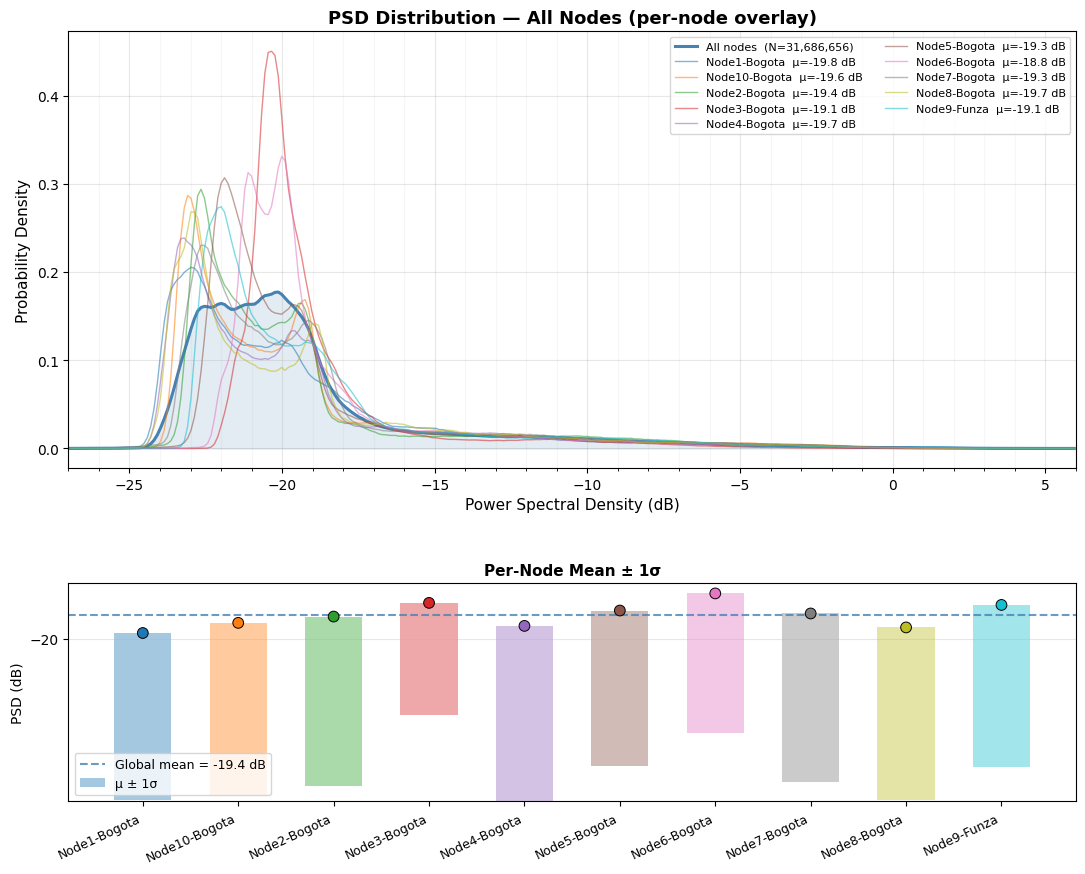


Node                  Mean (dB)   Std (dB)   Rows       Values
--------------------------------------------------------------
Node1-Bogota             -19.85       4.29    105    3,439,202
Node10-Bogota            -19.59       4.42    104    3,407,148
Node2-Bogota             -19.43       4.35    105    3,439,350
Node3-Bogota             -19.08       2.87    105    3,439,687
Node4-Bogota             -19.67       4.50    105    3,440,516
Node5-Bogota             -19.27       3.98    105    3,440,039
Node6-Bogota             -18.83       3.59    105    3,440,031
Node7-Bogota             -19.35       4.32    105    3,438,978
Node8-Bogota             -19.71       4.42     23      753,371
Node9-Funza              -19.13       4.17    105    3,440,357
--------------------------------------------------------------
GLOBAL                   -19.39       0.30          31,686,656


In [2]:
### Pxx Histogram Estimation
import ast
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm import tqdm

# ── Config ────────────────────────────────────────────────────────────────
N_BINS       = 300          # histogram resolution
#GLOBAL_RANGE = (pxx_array.min(), pxx_array.max())    # dB window — adjust if data falls outside
GLOBAL_RANGE = (-27, 6)
ALPHA_NODE   = 0.55         # per-node line opacity

# Node display order (sorted for legend consistency)
NODE_NAMES  = sorted(datos_nodos.keys(), key=lambda x: x.split('/')[-1])
N_NODES     = len(NODE_NAMES)
NODE_LABELS = [n.split('/')[-1] for n in NODE_NAMES]

# ── Step 1: Parse pxx and accumulate ──────────────────────────────────────
# Pre-allocate shared bin edges so every node uses the same grid
bin_edges   = np.linspace(GLOBAL_RANGE[0], GLOBAL_RANGE[1], N_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

global_counts = np.zeros(N_BINS, dtype=np.int64)   # aggregated across all nodes
node_counts   = {}                                  # per-node histogram counts
node_stats    = {}                                  # mean / std per node

total_values = 0
clipped      = 0  # values outside GLOBAL_RANGE

print(f"Parsing pxx across {N_NODES} nodes...")
for node_key, label in tqdm(zip(NODE_NAMES, NODE_LABELS), total=N_NODES):
    df   = datos_nodos[node_key]
    arrs = []

    for val in df['pxx']:
        # pxx may already be a parsed array (numpy) or still a string
        if isinstance(val, str):
            arr = np.array(ast.literal_eval(val), dtype=np.float32)
        else:
            arr = np.asarray(val, dtype=np.float32)
        arrs.append(arr)

    flat = np.concatenate(arrs)                    # shape: (n_rows × 32768,)
    total_values += flat.size
    clipped      += np.sum((flat < GLOBAL_RANGE[0]) | (flat > GLOBAL_RANGE[1]))

    counts, _ = np.histogram(flat, bins=bin_edges)
    node_counts[label]   = counts
    global_counts       += counts
    node_stats[label]    = {'mean': float(np.mean(flat)), 'std': float(np.std(flat))}

print(f"\n Parsed {total_values:,} values total")
if clipped:
    pct = 100 * clipped / total_values
    print(f"  {clipped:,} values ({pct:.2f}%) fall outside GLOBAL_RANGE {GLOBAL_RANGE} — adjust if needed")

# ── Step 2: Normalise to probability density ──────────────────────────────
bin_width      = bin_edges[1] - bin_edges[0]
global_density = global_counts / (global_counts.sum() * bin_width)
node_densities = {
    lbl: c / (c.sum() * bin_width)
    for lbl, c in node_counts.items()
}

# ── Step 3: Plot ───────────────────────────────────────────────────────────
cmap   = plt.cm.tab10
colors = [cmap(i / max(N_NODES - 1, 1)) for i in range(N_NODES)]

fig, axes = plt.subplots(2, 1, figsize=(13, 10),
                          gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.35},
                          layout='constrained')
# ── Panel A: Global + per-node overlay ────────────────────────────────────
ax = axes[0]
ax.fill_between(bin_centers, global_density, alpha=0.15, color='steelblue', label='_nolegend_')
ax.plot(bin_centers, global_density, color='steelblue', lw=2.2,
        label=f'All nodes  (N={total_values:,})')

for (lbl, density), color in zip(node_densities.items(), colors):
    mu  = node_stats[lbl]['mean']
    ax.plot(bin_centers, density, lw=1.0, alpha=ALPHA_NODE,
            color=color, label=f"{lbl}  μ={mu:.1f} dB")

ax.set_xlim(GLOBAL_RANGE)
ax.set_xlabel('Power Spectral Density (dB)', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title('PSD Distribution — All Nodes (per-node overlay)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.grid(True, which='major', alpha=0.3)
ax.grid(True, which='minor', alpha=0.1)

# ── Panel B: Mean ± 1σ per node (compact stats) ───────────────────────────
ax2    = axes[1]
labels = list(node_stats.keys())
means  = np.array([node_stats[l]['mean'] for l in labels])
stds   = np.array([node_stats[l]['std']  for l in labels])
xs     = np.arange(len(labels))

ax2.bar(xs, stds, bottom=means - stds, alpha=0.4, color=colors, width=0.6, label='μ ± 1σ')
ax2.scatter(xs, means, color=colors, zorder=5, s=60, edgecolors='black', lw=0.7)
ax2.axhline(np.mean(means), color='steelblue', lw=1.5, ls='--', alpha=0.8,
            label=f'Global mean = {np.mean(means):.1f} dB')

ax2.set_xticks(xs)
ax2.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
ax2.set_ylabel('PSD (dB)', fontsize=10)
ax2.set_title('Per-Node Mean ± 1σ', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_locator(ticker.MultipleLocator(5))
ax2.grid(True, axis='y', alpha=0.3)

#plt.suptitle('FM Band PSD Histogram  |  Bogotá–Funza Nodes  |  88–108 MHz',
#             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Step 4: Print stats table ──────────────────────────────────────────────
print(f"\n{'Node':<20} {'Mean (dB)':>10} {'Std (dB)':>10} {'Rows':>6} {'Values':>12}")
print('-' * 62)
for lbl in labels:
    n_rows = len(datos_nodos[
        next(k for k in NODE_NAMES if k.endswith(lbl))
    ])
    n_vals = node_counts[lbl].sum()
    print(f"{lbl:<20} {node_stats[lbl]['mean']:>10.2f} {node_stats[lbl]['std']:>10.2f} {n_rows:>6} {n_vals:>12,}")
print('-' * 62)
print(f"{'GLOBAL':<20} {np.mean(means):>10.2f} {float(np.std(means)):>10.2f} {'':>6} {total_values:>12,}")

In [3]:
# ── Correlation Matrix of PSD Histogram Shapes ────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import pearsonr

# Stack all per-node density curves into a matrix: shape (N_NODES, N_BINS)
density_matrix = np.stack([node_densities[lbl] for lbl in NODE_LABELS])

# Compute pairwise Pearson correlation between histogram shapes
corr_matrix = np.corrcoef(density_matrix)   # shape (N_NODES, N_NODES)

# ── Row-wise sum of the correlation matrix ─────────────────────────────────
# Each row i sums all Pearson r values between node i and every other node.
# Higher sum → node whose histogram shape is more similar to the rest.

row_sums = corr_matrix.sum(axis=1)          # shape: (N_NODES,)
# Subtract self-correlation (diagonal = 1.0) to get cross-node score only
cross_sums = row_sums - 1.0

# Rank by cross-node similarity
ranked = sorted(zip(NODE_LABELS, cross_sums), key=lambda x: x[1], reverse=True)
print(f"\n📊 Ranked by cross-node similarity:")
for rank, (label, cs) in enumerate(ranked, 1):
    flag = '  ⚠️  outlier' if cs < (cross_sums.mean() - cross_sums.std()) else ''
    print(f"  {rank}. {label:<22} Σr = {cs:.4f}{flag}")



📊 Ranked by cross-node similarity:
  1. Node7-Bogota           Σr = 7.5263
  2. Node2-Bogota           Σr = 7.3478
  3. Node10-Bogota          Σr = 7.1110
  4. Node1-Bogota           Σr = 7.0806
  5. Node4-Bogota           Σr = 6.9903
  6. Node9-Funza            Σr = 6.8889
  7. Node8-Bogota           Σr = 6.7255
  8. Node5-Bogota           Σr = 6.6630
  9. Node6-Bogota           Σr = 5.5784  ⚠️  outlier
  10. Node3-Bogota           Σr = 5.0046  ⚠️  outlier


| Goal | Minimum Spacing | Preferred Spacing |
|------|----------------|-------------------|
| Basic diversity (omni) | 0.75 m (¼ λ @ 88 MHz) | 1.5–3.0 m (½–1 λ) |
| High isolation / low coupling | 2.8 m | 7.6 m |
| Research-grade spatial independence | 3–6 m (urban) | 10–15 m (open) |
| Your Bogotá–Funza network | Already satisfied (nodes are km apart) | Focus on temporal alignment & calibration |

In [4]:
print("nodes to be excluded:", 'node6,node3')

nodes to be excluded: node6,node3


Loading CSVs: 100%|██████████| 9/9 [00:10<00:00,  1.14s/it]
Loaded 9 nodes from 9 files.
Node1-Bogota: center=98.000 MHz | noise_floor(Q0.20)=-23.09 dB | center_spike=3.93 dB | significant=False
Node10-Bogota: center=98.000 MHz | noise_floor(Q0.20)=-22.50 dB | center_spike=6.43 dB | significant=True
Node2-Bogota: center=98.000 MHz | noise_floor(Q0.20)=-22.84 dB | center_spike=4.82 dB | significant=False
Node3-Bogota: center=98.000 MHz | noise_floor(Q0.20)=-20.68 dB | center_spike=0.15 dB | significant=False
Node4-Bogota: center=98.000 MHz | noise_floor(Q0.20)=-23.37 dB | center_spike=3.14 dB | significant=False
Node5-Bogota: center=98.000 MHz | noise_floor(Q0.20)=-21.75 dB | center_spike=0.86 dB | significant=False
Node6-Bogota: center=98.000 MHz | noise_floor(Q0.20)=-20.91 dB | center_spike=1.85 dB | significant=False
Node7-Bogota: center=98.000 MHz | noise_floor(Q0.20)=-22.12 dB | center_spike=1.78 dB | significant=False
Node9-Funza: center=98.000 MHz | noise_floor(Q0.20)=-22.09 dB |

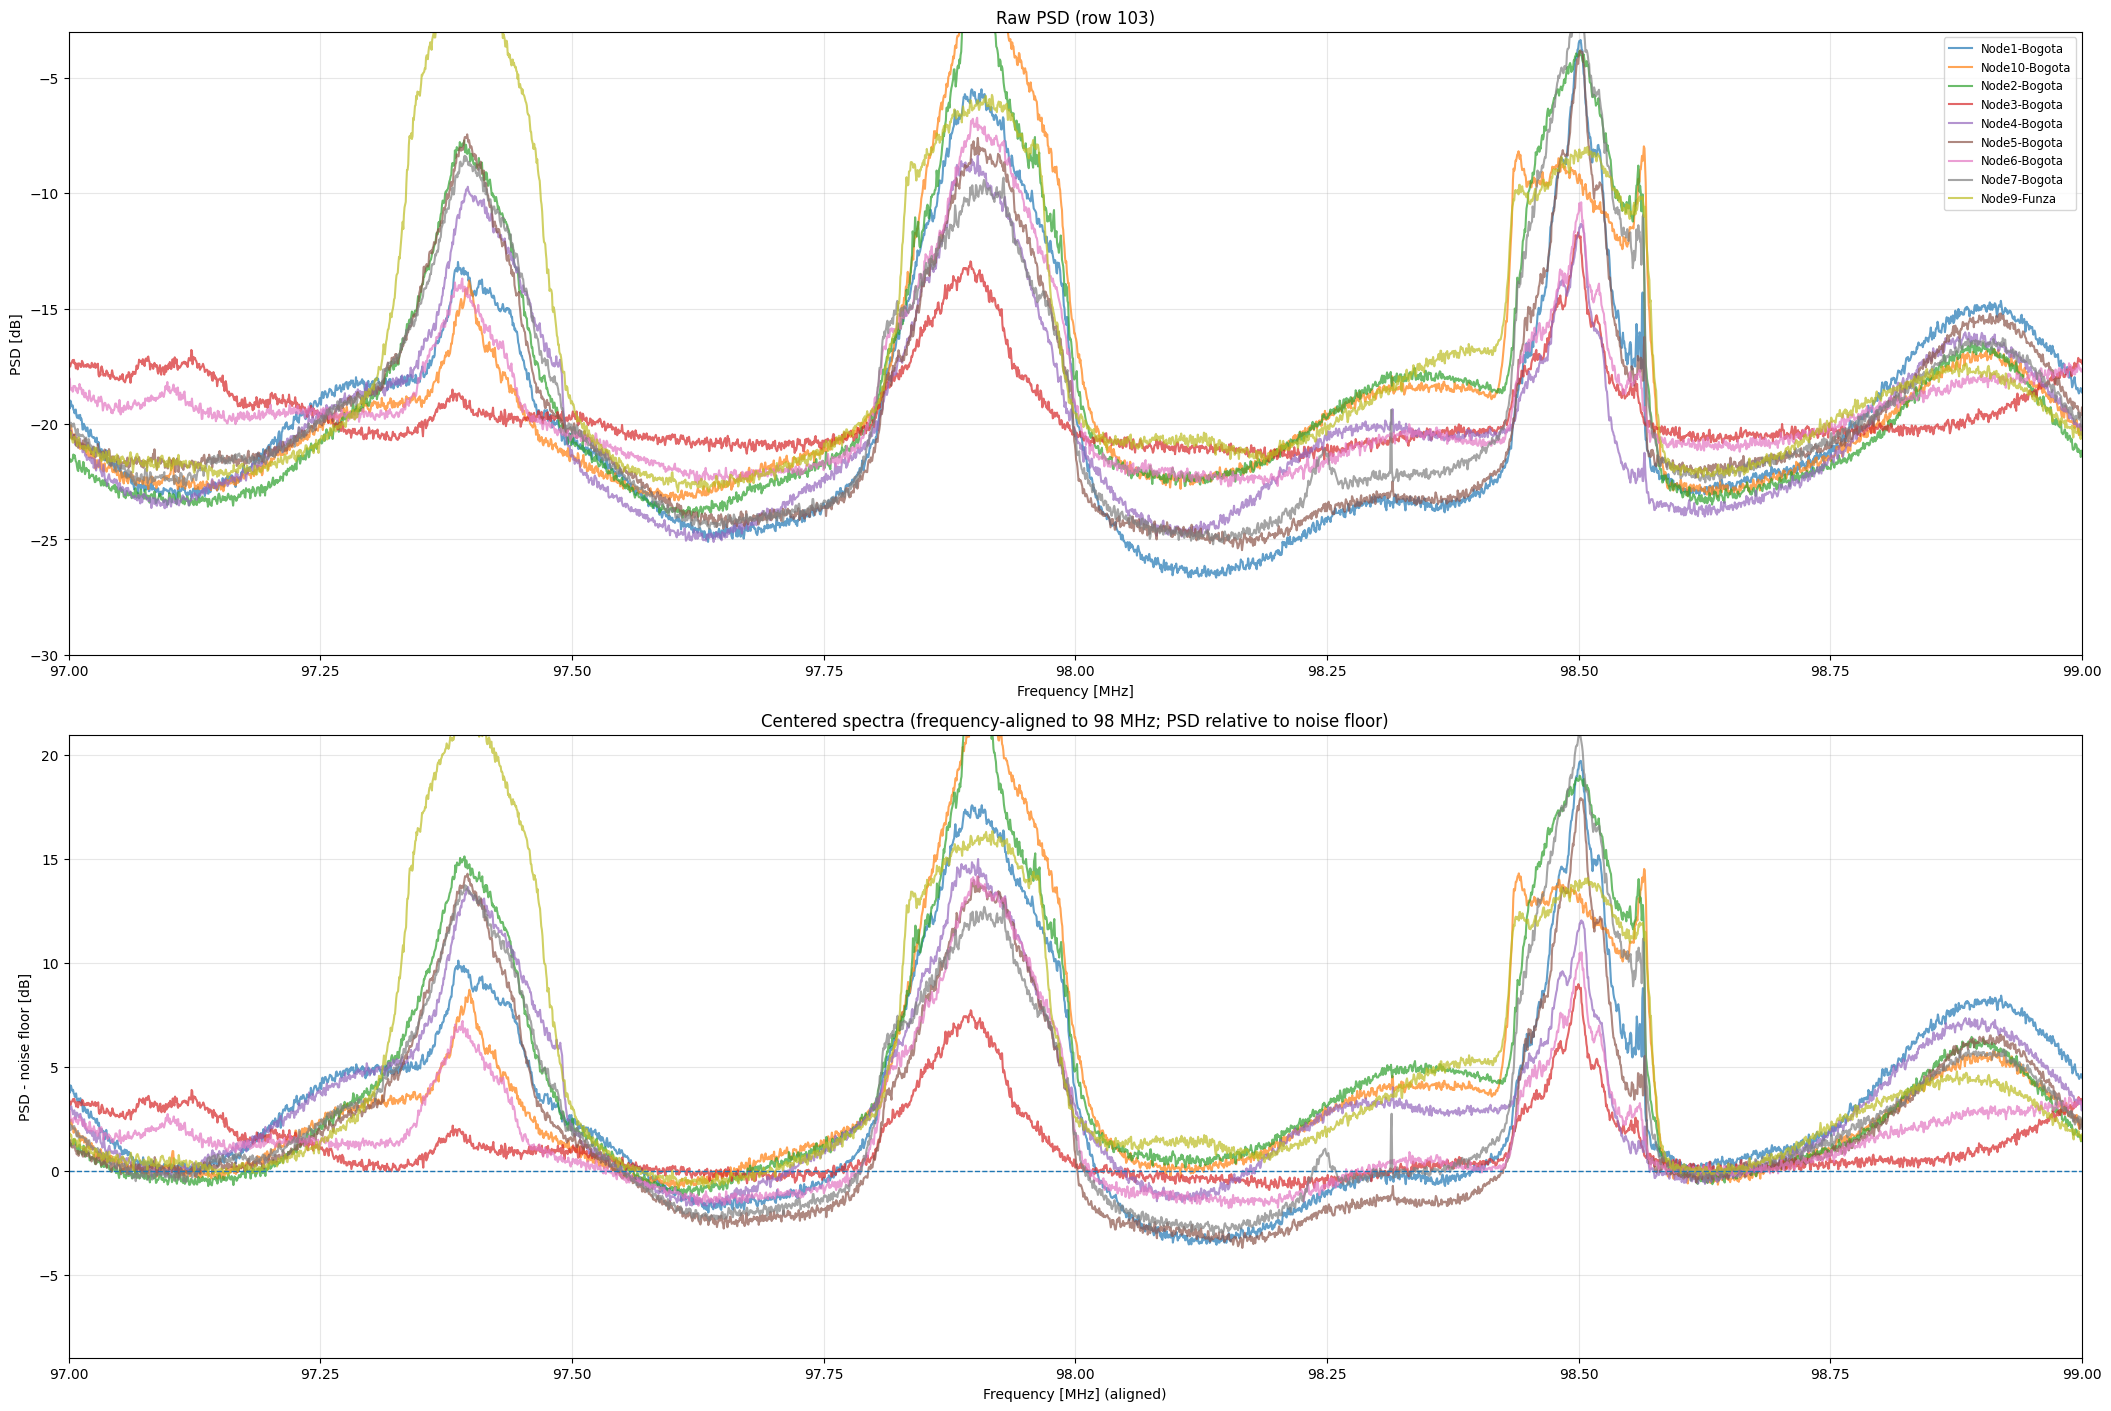


MI matrix (bits):
               Node1-Bogota  Node10-Bogota  Node2-Bogota  Node3-Bogota  Node4-Bogota  Node5-Bogota  Node6-Bogota  Node7-Bogota  Node9-Funza
Node1-Bogota         5.1408         1.4810        1.4746        0.5423        1.7051        1.5692        0.8978        1.7591       1.3169
Node10-Bogota        1.4810         4.9267        1.8520        0.5265        1.8705        1.5289        0.8747        1.5913       1.4159
Node2-Bogota         1.4746         1.8520        4.9996        0.5554        1.6167        1.5698        0.7932        1.7573       1.4804
Node3-Bogota         0.5423         0.5265        0.5554        4.3829        0.5932        0.5514        0.8346        0.5980       0.5174
Node4-Bogota         1.7051         1.8705        1.6167        0.5932        5.1686        1.6513        0.9421        1.6660       1.4295
Node5-Bogota         1.5692         1.5289        1.5698        0.5514        1.6513        4.7626        0.9859        1.5939       1.3096
N

In [5]:
import glob, os, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

def load_node_csvs(
    root_pattern: str,
    *,
    exclude_basenames=None,
    read_csv_kwargs=None,
    show_progress: bool = True,
):
    exclude_raw = set(exclude_basenames or [])
    exclude = {
        os.path.splitext(os.path.basename(x))[0]
        for x in exclude_raw
    }
    read_csv_kwargs = dict(read_csv_kwargs or {})

    archivos_all = sorted(glob.glob(root_pattern))
    archivos = [
        p for p in archivos_all
        if os.path.splitext(os.path.basename(p))[0] not in exclude
    ]

    iterator = tqdm(archivos, desc="Loading CSVs") if show_progress else archivos

    datos_nodos = {}
    errors = []
    for archivo in iterator:
        nombre_nodo = os.path.splitext(os.path.basename(archivo))[0]
        try:
            datos_nodos[nombre_nodo] = pd.read_csv(archivo, **read_csv_kwargs)
        except Exception as e:
            errors.append((archivo, str(e)))

    return datos_nodos, archivos, errors

def parse_pxx_cell(pxx_raw):
    """Parse a CSV cell containing a list-like PSD into a 1D float array."""
    if isinstance(pxx_raw, (list, tuple, np.ndarray, pd.Series)):
        return np.asarray(pxx_raw, dtype=float).ravel()

    s = str(pxx_raw).strip()
    if not s:
        return np.array([], dtype=float)

    if s.startswith("[") and s.endswith("]"):
        body = s[1:-1].replace(",", " ")
        arr = np.fromstring(body, sep=" ", dtype=float)
        if arr.size > 0:
            return arr

    return np.asarray(ast.literal_eval(s), dtype=float).ravel()

def get_frequency_axis_mhz(df, row_idx, pxx_len, default_band=(88.0, 108.0)):
    """
    Return frequency axis in MHz for the PSD vector at row_idx.
    Priority:
      1) freq_mhz column, if present and valid
      2) derive from sample_rate_hz + center_freq_hz
      3) fallback to default_band
    """
    if "freq_mhz" in df.columns:
        try:
            freqs_mhz = parse_pxx_cell(df["freq_mhz"].iloc[row_idx])
            if freqs_mhz.size == pxx_len:
                return freqs_mhz
        except Exception:
            pass

    if {"sample_rate_hz", "center_freq_hz"}.issubset(df.columns):
        try:
            fs_mhz = float(df["sample_rate_hz"].iloc[row_idx]) / 1e6
            fc_mhz = float(df["center_freq_hz"].iloc[row_idx]) / 1e6

            # More consistent with a band-centered RF spectrum
            freqs_mhz = np.linspace(
                fc_mhz - fs_mhz / 2.0,
                fc_mhz + fs_mhz / 2.0,
                pxx_len,
                endpoint=True,
            )
            return freqs_mhz
        except Exception:
            pass

    return np.linspace(default_band[0], default_band[1], pxx_len, endpoint=True)

def to_db(pxx, *, scale="dB", eps=1e-12):
    pxx = np.asarray(pxx, dtype=float)
    if scale == "linear":
        pxx_db = 10.0 * np.log10(np.maximum(pxx, eps))
    elif scale == "dB":
        pxx_db = pxx.copy()
    else:
        raise ValueError("scale must be 'dB' or 'linear'")
    return np.where(np.isfinite(pxx_db), pxx_db, np.nan)

def detect_center_spike(
    frequencies,
    pxx,
    *,
    scale="dB",
    target_freq=None,
    guard_bins=2,
    baseline_mode="median",  # "median" or "quantile"
    baseline_q=0.2,
    threshold_db=6.0,
    eps=1e-12,
):
    pxx = np.asarray(pxx, dtype=float).ravel()
    freqs = np.asarray(frequencies, dtype=float).ravel()
    if pxx.size == 0 or freqs.size != pxx.size:
        raise ValueError("frequencies and pxx must be same non-zero length")

    # spike bin index
    if target_freq is None:
        k0 = pxx.size // 2
    else:
        k0 = int(np.argmin(np.abs(freqs - float(target_freq))))

    pxx_db = to_db(pxx, scale=scale, eps=eps)

    idx = np.arange(pxx_db.size)
    mask = np.abs(idx - k0) > int(guard_bins)
    if not np.any(mask):
        raise ValueError("guard_bins too large for PSD length")

    baseline_vals = pxx_db[mask]
    if baseline_mode == "median":
        baseline_db = np.nanmedian(baseline_vals)
    elif baseline_mode == "quantile":
        baseline_db = np.nanquantile(baseline_vals, baseline_q)
    else:
        raise ValueError("baseline_mode must be 'median' or 'quantile'")

    center_db = pxx_db[k0]
    spike_db = center_db - baseline_db
    spike_ratio = 10.0 ** (spike_db / 10.0)
    is_significant = bool(spike_db >= threshold_db)

    return dict(
        index=k0,
        freq=freqs[k0],
        baseline_db=baseline_db,
        center_db=center_db,
        spike_db=spike_db,
        spike_ratio=spike_ratio,
        is_significant=is_significant,
        pxx_db=pxx_db,
        mask_baseline=mask,
    )

def estimate_noise_floor_db(pxx_db, mask=None, q=0.2):
    """Noise floor estimate via low quantile (robust against carriers)."""
    vals = pxx_db[mask] if mask is not None else pxx_db
    return float(np.nanquantile(vals, q))

def _entropy_1d_from_hist(p, *, base=2.0):
    """Entropy from a probability vector p."""
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    H = -np.sum(p * np.log(p))
    return H / np.log(base)

def mutual_information_hist(
    x: np.ndarray,
    y: np.ndarray,
    *,
    bins=64,
    x_edges=None,
    y_edges=None,
    value_range=None,
    base: float = 2.0,
    normalized: bool = False,
    eps: float = 1e-15,
):
    """
    Histogram-based mutual information between 1D arrays x and y.
    Returns MI in 'base' units (bits if base=2).
    """
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if x.size == 0:
        return np.nan

    if x_edges is None or y_edges is None:
        if value_range is None:
            lo = float(np.nanmin(np.concatenate([x, y])))
            hi = float(np.nanmax(np.concatenate([x, y])))
        else:
            lo, hi = map(float, value_range)

        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            return np.nan

        x_edges = np.linspace(lo, hi, int(bins) + 1)
        y_edges = np.linspace(lo, hi, int(bins) + 1)

    Hxy, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
    Pxy = Hxy / (np.sum(Hxy) + eps)

    Px = np.sum(Pxy, axis=1)
    Py = np.sum(Pxy, axis=0)

    denom = (Px[:, None] * Py[None, :]) + eps
    ratio = (Pxy + eps) / denom
    MI = np.sum(Pxy * np.log(ratio))
    MI = MI / np.log(base)

    if not normalized:
        return MI

    Hx = _entropy_1d_from_hist(Px, base=base)
    Hy = _entropy_1d_from_hist(Py, base=base)
    if not np.isfinite(Hx) or not np.isfinite(Hy) or Hx <= 0 or Hy <= 0:
        return np.nan

    return MI / np.sqrt(Hx * Hy)


def compute_mi_matrix(
    vectors_by_node: dict,
    *,
    bins: int = 64,
    qrange=(1.0, 99.0),
    base: float = 2.0,
    normalized: bool = False,
):
    """
    Compute MI matrix across nodes using a global bin range.
    Returns: (mi_df, used_range)
    """
    names = sorted(vectors_by_node.keys())
    if len(names) == 0:
        return pd.DataFrame(), None

    all_vals = []
    for n in names:
        v = np.asarray(vectors_by_node[n], dtype=float).ravel()
        v = v[np.isfinite(v)]
        if v.size:
            all_vals.append(v)

    if not all_vals:
        return pd.DataFrame(index=names, columns=names, dtype=float), None

    all_vals = np.concatenate(all_vals)
    lo = float(np.nanpercentile(all_vals, qrange[0]))
    hi = float(np.nanpercentile(all_vals, qrange[1]))

    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo = float(np.nanmin(all_vals))
        hi = float(np.nanmax(all_vals))

    edges = np.linspace(lo, hi, int(bins) + 1)

    M = np.full((len(names), len(names)), np.nan, dtype=float)
    for i, ni in enumerate(names):
        xi = vectors_by_node[ni]
        for j, nj in enumerate(names):
            if j < i:
                M[i, j] = M[j, i]
                continue

            yj = vectors_by_node[nj]
            mij = mutual_information_hist(
                xi,
                yj,
                x_edges=edges,
                y_edges=edges,
                base=base,
                normalized=normalized,
            )
            M[i, j] = mij
            M[j, i] = mij

    mi_df = pd.DataFrame(M, index=names, columns=names)
    return mi_df, (lo, hi)

def build_vectors_for_row(
    datos_nodos: dict,
    row_idx: int,
    *,
    pxx_col: str = "pxx",
    pxx_scale: str = "dB",
    center_freq_mhz: float = 98.0,
    guard_bins: int = 2,
    noise_q: float = 0.2,
    roi=(97.0, 99.0),
    grid_n: int = 512,
):
    """
    For a given row, return dict {node: vector_on_common_grid}, where each vector is:
      - PSD in dB
      - noise-floor centered (pxx_db - noise_floor)
      - frequency-aligned so detected center bin maps to center_freq_mhz
      - interpolated onto a shared frequency grid in roi
    """
    fmin, fmax = map(float, roi)
    grid = np.linspace(fmin, fmax, int(grid_n))

    vectors = {}

    for nombre_nodo, df in datos_nodos.items():
        if pxx_col not in df.columns:
            continue
        if not (0 <= row_idx < len(df)):
            continue

        try:
            pxx = parse_pxx_cell(df[pxx_col].iloc[row_idx])
        except Exception:
            continue

        if pxx.size == 0:
            continue

        freqs_mhz = get_frequency_axis_mhz(df, row_idx, pxx.size)

        if freqs_mhz.size != pxx.size:
            continue

        # Ensure monotone axis for interpolation
        order = np.argsort(freqs_mhz)
        freqs_mhz = freqs_mhz[order]
        pxx = pxx[order]

        res = detect_center_spike(
            freqs_mhz,
            pxx,
            scale=pxx_scale,
            target_freq=center_freq_mhz,
            guard_bins=guard_bins,
            baseline_mode="quantile",
            baseline_q=noise_q,
            threshold_db=6.0,
        )

        noise_floor_db = res["baseline_db"]

        freqs_aligned_mhz = freqs_mhz + (center_freq_mhz - res["freq"])
        pxx_centered = res["pxx_db"] - noise_floor_db

        y = np.interp(grid, freqs_aligned_mhz, pxx_centered, left=np.nan, right=np.nan)

        if np.isfinite(y).sum() < max(16, grid_n // 10):
            continue

        vectors[nombre_nodo] = y

    return grid, vectors, list(vectors.keys())

def cumulative_mi_scores_for_row(
    vectors_by_node: dict,
    *,
    mi_bins: int = 64,
    qrange=(1, 99),
    base: float = 2.0,
    normalized: bool = False,
):
    """
    Compute MI matrix and cumulative MI score per node (row-sum, diagonal excluded).
    Returns: (mi_df, scores_series)
    """
    mi_df, _ = compute_mi_matrix(
        vectors_by_node,
        bins=mi_bins,
        qrange=qrange,
        base=base,
        normalized=normalized,
    )

    # exclude diagonal
    mi_no_diag = mi_df.copy()
    np.fill_diagonal(mi_no_diag.values, 0.0)

    scores = mi_no_diag.sum(axis=1, skipna=True).astype(float)
    return mi_df, scores

import numpy as np
import pandas as pd

def _row_to_numeric_1d(df: pd.DataFrame, row_idx: int) -> np.ndarray:
    row = df.iloc[row_idx].copy()

    # Convert everything to string first
    s = row.astype(str).str.strip()

    # Remove common unit suffixes such as dB, Hz, MHz
    s = s.str.replace(r"\s*(dB|Hz|kHz|MHz)\s*$", "", regex=True)

    # Optional: remove thousands separators
    s = s.str.replace(",", "", regex=False)

    # Convert safely
    x = pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)

    # Keep only valid numbers
    x = x[np.isfinite(x)]

    if x.size == 0:
        raise ValueError(f"Row {row_idx} has no valid numeric values after cleaning.")

    return x


def compute_rankings_over_rows(
    datos_nodos,
    row_range,
    *,
    pxx_scale="dB",
    center_freq_mhz=98.0,
    guard_bins=2,
    noise_q=0.2,
    roi=(97.0, 99.0),
    grid_n=512,
    mi_bins=64,
    normalized=False,
    verbose=False,
):
    """
    True row-wise cumulative-MI ranking:
      for each row:
        1) build aligned / centered spectra per node
        2) compute MI matrix across nodes
        3) compute cumulative MI score per node
        4) rank nodes by descending score
    """
    node_names = sorted(datos_nodos.keys())
    row_range = list(row_range)

    if len(node_names) == 0:
        raise ValueError("datos_nodos is empty.")
    if len(row_range) == 0:
        raise ValueError("row_range is empty.")

    scores_rows = []
    ranks_rows = []

    for r in row_range:
        _, vectors_by_node, _ = build_vectors_for_row(
            datos_nodos,
            r,
            pxx_col="pxx",
            pxx_scale=pxx_scale,
            center_freq_mhz=center_freq_mhz,
            guard_bins=guard_bins,
            noise_q=noise_q,
            roi=roi,
            grid_n=grid_n,
        )

        row_scores = pd.Series(index=node_names, dtype=float, name=r)

        if len(vectors_by_node) >= 2:
            _, scores = cumulative_mi_scores_for_row(
                vectors_by_node,
                mi_bins=mi_bins,
                qrange=(1, 99),
                base=2.0,
                normalized=normalized,
            )
            row_scores.loc[scores.index] = scores

        if verbose:
            n_used = int(row_scores.notna().sum())
            print(f"Row {r}: used {n_used} nodes")

        scores_rows.append(row_scores)

        row_ranks = row_scores.rank(ascending=False, method="dense")
        ranks_rows.append(row_ranks)

    scores_df = pd.DataFrame(scores_rows)
    ranks_df = pd.DataFrame(ranks_rows)

    return scores_df, ranks_df

def plot_rank_trajectories(ranks_df: pd.DataFrame, *, top_k: int = 8, title="Node rank vs ROW_PLOT"):
    """
    Plot rank (1=best) trajectories for top_k nodes chosen by best median rank.
    """
    # choose nodes with best (lowest) median rank across rows
    med = ranks_df.median(axis=0, skipna=True).sort_values()
    nodes = med.index[:top_k]

    plt.figure(figsize=(14, 6))
    x = ranks_df.index.values
    for n in nodes:
        plt.plot(x, ranks_df[n].values, marker="o", linewidth=1, label=n)

    plt.gca().invert_yaxis()
    plt.xlabel("ROW_PLOT")
    plt.ylabel("Rank (1 = best)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best", fontsize="small")
    plt.tight_layout()
    plt.show()


def plot_score_trajectories(scores_df: pd.DataFrame, *, top_k: int = 8, title="Cumulative MI score vs ROW_PLOT"):
    """
    Plot score trajectories for top_k nodes chosen by highest median score.
    """
    med = scores_df.median(axis=0, skipna=True).sort_values(ascending=False)
    nodes = med.index[:top_k]

    plt.figure(figsize=(14, 6))
    x = scores_df.index.values
    for n in nodes:
        plt.plot(x, scores_df[n].values, marker="o", linewidth=1, label=n)

    plt.xlabel("ROW_PLOT")
    plt.ylabel("Cumulative MI (row-sum, diag excluded)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best", fontsize="small")
    plt.tight_layout()
    plt.show()

# -----------------------
# Config
# -----------------------
ROOT_PATTERN = "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv"

EXCLUDE_BASENAME  = {
    "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node8-Bogota", # not enough data
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node5-Bogota", # atipical 
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node6-Bogota", # poor quality -- brocken mux 
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node3-Bogota", # poorest measure quality -- without antenna
}
ROW_PLOT = 103

# each CSV row is already an averaged Welch PSD
# PSD format
PXX_SCALE = "dB"       # "dB" if stored in dB, "linear" if stored as linear power
CENTER_FREQ_MHZ = 98.0 # analysis center (band center)

# (1) Compute guard dynamically from actual bin resolution:
# Compute GUARD_BINS from FM band constants — no runtime dependency
FM_BAND_MHZ    = 20.0          # 108 - 88 MHz
DEFAULT_N_BINS = 1024          # typical FFT size; adjust if different
bin_res_mhz    = FM_BAND_MHZ / (DEFAULT_N_BINS - 1)
fm_half_bw_mhz = 0.200         # ±200 kHz FM occupied BW
GUARD_BINS     = int(np.ceil(fm_half_bw_mhz / bin_res_mhz)) + 1  # ✅

NOISE_Q = 0.2          # 20th percentile

datos_nodos, archivos, errors = load_node_csvs(
    ROOT_PATTERN,
    exclude_basenames=EXCLUDE_BASENAME,
    show_progress=True,
)

print(f"Loaded {len(datos_nodos)} nodes from {len(archivos)} files.")
if errors:
    print("Errors:")
    for f, msg in errors:
        print(f"  {f}: {msg}")

# -----------------------
# Plot (top: raw PSD, bottom: centered)
# -----------------------
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(21, 14), sharex=False, constrained_layout=True)

pxx_centered_by_node = {}   # add before the loop
noise_floors = {}  
for nombre_nodo, df in datos_nodos.items():
    if "pxx" not in df.columns:
        print(f"⚠️ {nombre_nodo}: missing 'pxx' column")
        continue
    if not (0 <= ROW_PLOT < len(df)):
        print(f"⚠️ {nombre_nodo}: ROW_PLOT out of range")
        continue

    # parse PSD vector
    try:
        pxx = parse_pxx_cell(df["pxx"].iloc[ROW_PLOT])
    except Exception as e:
        print(f"⚠️ {nombre_nodo}: failed to parse pxx: {e}")
        continue

    if pxx.size == 0:
        print(f"⚠️ {nombre_nodo}: empty pxx")
        continue

    # Placeholder RF axis (replace with true bin centers if available in CSV)
    freqs_mhz = np.linspace(88.0, 108.0, pxx.size, endpoint=True)

    # detect spike + get baseline mask
    res = detect_center_spike(
        freqs_mhz, pxx,
        scale=PXX_SCALE,
        target_freq=CENTER_FREQ_MHZ,
        guard_bins=GUARD_BINS,
        baseline_mode="quantile",  # better for noise floor in presence of carriers
        baseline_q=NOISE_Q,
        threshold_db=6.0,
    )

    # Noise floor estimate (explicit)
    noise_floor_db = estimate_noise_floor_db(res["pxx_db"], mask=res["mask_baseline"], q=NOISE_Q)
    noise_floors[nombre_nodo] = noise_floor_db 

    # --- TOP: raw PSD (use dB if already in dB; else plot converted dB)
    ax_top.plot(freqs_mhz, res["pxx_db"], label=nombre_nodo, alpha=0.7)

    # --- BOTTOM: centered (keep RF MHz axis 97..99)
    # 1) frequency-align so each node's detected center bin maps to CENTER_FREQ_MHZ (e.g., 98.0)
    freqs_aligned_mhz = freqs_mhz + (CENTER_FREQ_MHZ - res["freq"])

    # 2) level-center: subtract node noise floor so all floors align
    pxx_centered = res["pxx_db"] - noise_floor_db
    pxx_centered_by_node[nombre_nodo] = pxx_centered

    ax_bot.plot(freqs_aligned_mhz, pxx_centered, label=nombre_nodo, alpha=0.7)
    print(
        f"{nombre_nodo}: "
        f"center={res['freq']:.3f} MHz | "
        f"noise_floor(Q{NOISE_Q:.2f})={noise_floor_db:.2f} dB | "
        f"center_spike={res['spike_db']:.2f} dB | "
        f"significant={res['is_significant']}"
    )

mi_df, used_range = compute_mi_matrix(
    pxx_centered_by_node,
    bins=64,
    qrange=(1, 99),
    base=2.0,
    normalized=False,   # set True if you want NMI
)

# cosmetics
ax_top.set_title(f"Raw PSD (row {ROW_PLOT})")
ax_top.set_xlabel("Frequency [MHz]")
ax_top.set_ylabel("PSD [dB]")
ax_top.grid(True, alpha=0.3)
ax_top.set_xlim(97, 99)
ax_top.set_ylim(-30 , -3 )
ax_top.legend(loc="best", fontsize="small")

ax_bot.set_title("Centered spectra (frequency-aligned to 98 MHz; PSD relative to noise floor)")
ax_bot.set_xlabel("Frequency [MHz] (aligned)")
ax_bot.set_ylabel("PSD - noise floor [dB]")
ax_bot.axhline(0.0, linestyle="--", linewidth=1.0)  # noise floor reference
ax_bot.grid(True, alpha=0.3)
ax_bot.set_ylim(-9 , 21)
ax_bot.set_xlim(97, 99)
plt.show()

print("\nMI matrix (bits):")
print(mi_df.round(4).to_string())

# --- Option B (usually better for comparing nodes): exclude diagonal self-MI ---
mi_no_diag = mi_df.copy()
np.fill_diagonal(mi_no_diag.values, 0.0)
row_sum_no_diag = mi_no_diag.sum(axis=1)

# Choose which one you want to use for ranking/plot:
scores = row_sum_no_diag   # <- recommended
# scores = row_sum_all     # <- literal interpretation

# Rank in decreasing order
scores_sorted = scores.sort_values(ascending=False)

print("\nCumulative estimate (descending):")
print(scores_sorted.to_string())


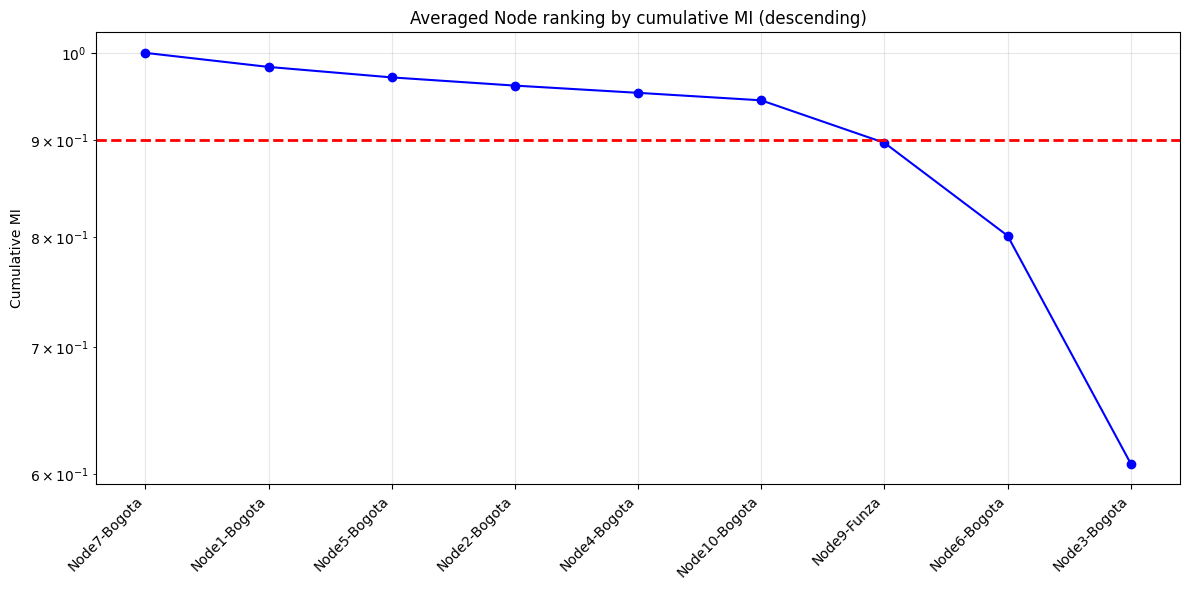


Average cumulative MI score per node (descending):
Node7-Bogota     1.0000
Node1-Bogota     0.9831
Node5-Bogota     0.9707
Node2-Bogota     0.9611
Node4-Bogota     0.9527
Node10-Bogota    0.9441
Node9-Funza      0.8967
Node6-Bogota     0.8012
Node3-Bogota     0.6078


In [12]:
# -----------------------
# Averaged cumulative MI ranking over all rows
# -----------------------
scores_df, ranks_df = compute_rankings_over_rows(
    datos_nodos,
    row_range=range(0, 104),
    pxx_scale=PXX_SCALE,
    center_freq_mhz=CENTER_FREQ_MHZ,
    guard_bins=GUARD_BINS,
    noise_q=NOISE_Q,
    roi=(97.0, 99.0),
    grid_n=512,
    mi_bins=64,
    normalized=False,
    verbose=False,
)

avg_scores = (
    scores_df.mean(axis=0, skipna=True)
    .sort_values(ascending=False)
    .pipe(lambda s: s  / s.max() )
    .round(4)
)

scores_sorted = avg_scores.sort_values(ascending=False)
# Plot
plt.figure(figsize=(12, 6))
plt.semilogy(avg_scores.values, color="blue",marker="o")
plt.xticks(range(len(scores_sorted.index)), scores_sorted.index, rotation=45, ha="right")

plt.axhline(y=.9, color='r', linestyle='--', linewidth=2, label='no antenna')
plt.ylabel("Cumulative MI")
plt.title("Averaged Node ranking by cumulative MI (descending)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAverage cumulative MI score per node (descending):")
print(avg_scores.round(4).to_string())